# Meta-Reinforcement Learning with MAML

In this assignment notebook, we will implement **Model-Agnostic Meta-Learning (MAML)** from scratch for a custom `HalfCheetahBackward` environment. The goal is to learn policy parameters that can quickly adapt to new tasks in this case, running the HalfCheetah agent **backward** with just a few gradient steps. Each section below provides context and key steps.

In [15]:
!pip -q install gymnasium[mujoco]
!pip install imageio -q


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Environment & Dependencies


In [16]:
import gymnasium as gym
import random
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from collections import namedtuple, deque
import imageio
from copy import deepcopy
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
from torch.distributions import Categorical

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
device

device(type='cpu')


This is necessary for running the HalfCheetah env on colab.

In [17]:
# %env MUJOCO_GL=egl

This code displays a saved mp4 file.

In [18]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path):
    mp4 = open(path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

Run this code to get started with the HalfCheetah environment.

In [19]:
env = gym.make("HalfCheetah-v5", render_mode="rgb_array")
env.reset()
frames = []

for _ in range(100):
    frames.append(env.render())
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        env.reset()

env.close()
imageio.mimsave('./HalfCheetah.mp4', frames, fps=20)
show_video('./HalfCheetah.mp4')

We modify the HalfCheetah environment by creating a wrapper on top it to reward the model for moving backwards.

In [20]:
class HalfCheetahBackward(gym.Env):
    def __init__(self):
        super().__init__()
        self.env = gym.make("HalfCheetah-v5", render_mode="rgb_array")
        self.forward_reward_weight = 1.0
        self.ctrl_cost_weight = 0.05

    def reset(self, *, seed=None, options=None):
        return self.env.reset(seed=seed, options=options)[0]

    def step(self, action):
        obs, _, done, tr, info = self.env.step(action)
        reward =  -1 * self.forward_reward_weight * info["reward_forward"] + self.ctrl_cost_weight * info["reward_ctrl"]
        return obs, reward, done, tr, info

    def render(self):
        return self.env.render()

    def close(self):
        self.env.close()

## Gaussian Policy Network
We parameterize our policy π_θ(a|s) as a multivariate Gaussian:
\[
$μ_θ(s) = f_θ(s), \quad Σ_θ = \text{diag}(\exp(2φ))$
\]
Here, `mean_head` outputs μ_θ(s) and `log_std` (φ) is a learned vector of log-standard deviations. Sampling and computing log-probabilities from this distribution is essential for the policy gradient update.

In [21]:
class Policy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        in_size = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        self.net = nn.Sequential(*layers)
        self.mean_head = nn.Linear(in_size, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))

    def forward(self, x):
        h = self.net(x)
        mean = self.mean_head(h)
        std = torch.exp(self.log_std)
        return mean, std

    def get_action(self, obs):
        mean, std = self(obs)
        dist = Normal(mean, std)
        action = dist.sample()
        return action, dist

## Trajectory Collection & Return Computation
The `rollout` function runs the policy in the environment for up to `max_steps`, storing:
- Observations **s_t**
- Actions **a_t** sampled from π_θ
- Log-probabilities **log π_θ(a_t|s_t)**
- Rewards **r_t**
After the episode, we compute discounted returns:
\[
$G_t = \sum_{k=0}^{T-t} γ^k r_{t+k}$
\]
These returns serve as our baselines for policy gradient estimation.

In [22]:
def rollout(env, policy, max_steps=200, gamma=0.99):
    obs = env.reset()
    obs_buf, logp_buf, ret_buf = [], [], []
    rewards = []
    for _ in range(max_steps):
        # Gather obs_buf, logp_buf, rewards
        action, dist = policy.get_action(torch.tensor(obs, dtype=torch.float32).to(device))
        obs, reward, done, truncated, info = env.step(action.cpu().numpy())
        logp = dist.log_prob(action).sum(-1)
        obs_buf.append(obs)
        logp_buf.append(logp)
        rewards.append(reward)
        if done or truncated:
            env.reset()

    returns = []
    G = 0
    for r in reversed(rewards):
        # Calculate discounted returns
        G = r + gamma * G
        returns.insert(0, G)
    logp_buf = torch.stack(logp_buf)
    # print(logp_buf[0].shape, type(logp_buf[0]), len(logp_buf))
    # obs_buf = torch.tensor(obs_buf, dtype=torch.float32)
    ret_buf = torch.tensor(returns, dtype=torch.float32).to(device)
    return obs_buf, logp_buf, ret_buf

Complete this section to evaluate the model and save a sample trajectory.

In [23]:
def evaluate(model, env, num_episodes=10, max_episode_len=200, path="./Final_Evaluation.mp4", no_video=False):
    frames = []
    mean_rewards = 0
    for episode in range(num_episodes):
        # Evaluate the model over `num_episodes`
        # Record on trajectory to be shown if `no_video` is False
        model.eval()
        obs = env.reset()
        total_reward = 0
        for t in range(max_episode_len):
            action, _ = model.get_action(torch.tensor(obs, dtype=torch.float32).to(device))
            obs, reward, done, truncated, info = env.step(action.cpu().numpy())
            total_reward += reward
            if not no_video:
                frames.append(env.render())
            if done or truncated:
                break
        mean_rewards += total_reward

    mean_rewards /= num_episodes
    print(f"Mean Reward: {mean_rewards}")
    if not no_video:
        imageio.mimsave(path, frames, fps=20)
    env.close()

## Model-Agnostic Meta-Learning (MAML)
MAML seeks initial parameters $\theta$ that can adapt to a new task with only a few gradient steps. For each task Tᵢ, we perform an **inner loop** update:

\[
$\theta'_i = \theta - α \nabla_\theta \mathcal{L}_{T_i}(\theta)$
\]

Then, the **meta-objective** (outer loop) minimizes the post-adaptation loss (optimize for the initial parameter $\theta$):

\[
$\min_\theta \sum_i \mathcal{L}_{T_i}(\theta'_i) = \sum_i \mathcal{L}_{T_i}\bigl(\theta - α \nabla_\theta \mathcal{L}_{T_i}(\theta)\bigr)$
\]


In [24]:
class MAML:
    def __init__(
        self,
        task_env_cls,
        inner_lr,
        outer_lr,
        inner_steps,
        meta_batch_size,
        max_episode_len=200,
        gamma=0.99
    ):
        self.task_env_cls = task_env_cls
        self.inner_lr = inner_lr
        self.inner_steps = inner_steps
        self.meta_batch_size = meta_batch_size
        self.max_episode_len = max_episode_len
        self.gamma = gamma
        self.loss_history   = []
        self.reward_history = []

        obs_dim = self.task_env_cls().env.observation_space.shape[0]
        act_dim = self.task_env_cls().env.action_space.shape[0]

        self.meta_policy = Policy(obs_dim, act_dim).to(device)
        self.meta_opt = torch.optim.Adam(self.meta_policy.parameters(), lr=outer_lr, weight_decay=1e-4)

    def inner_update(self, env):
        obs_s, logp_s, ret_s = rollout(env, self.meta_policy, self.max_episode_len, self.gamma)
        # print(logp_s.device, ret_s.device)
        pg_loss = -torch.mean(logp_s * ret_s)

        l2_reg = 1e-3
        l2_loss = sum(torch.norm(p) ** 2 for p in self.meta_policy.parameters())
        loss_s = pg_loss + l2_reg * l2_loss

        grads = torch.autograd.grad(loss_s, self.meta_policy.parameters(), create_graph=True)
        return grads

    def adapt_policy(self, grads):
        adapted = deepcopy(self.meta_policy)
        for param, grad in zip(adapted.parameters(), grads):
            param.data -= self.inner_lr * grad
        return adapted

    def meta_step(self):
        total_meta_loss = 0.0
        total_reward = 0.0

        for _ in range(self.meta_batch_size):
            env = self.task_env_cls()

            grads = self.inner_update(env)

            # Get adapted policy (use grads to update weights)
            adapted = self.adapt_policy(grads)

            obs_q, logp_q, ret_q = rollout(env, adapted, self.max_episode_len, self.gamma)
            loss_q = -torch.mean(logp_q * ret_q)
            total_meta_loss += loss_q

            total_reward += ret_q.mean().item()

            env.close()

        meta_loss = total_meta_loss / self.meta_batch_size
        self.meta_opt.zero_grad()
        meta_loss.backward()
        self.meta_opt.step()

        self.loss_history.append(meta_loss.item())
        self.reward_history.append(total_reward / self.meta_batch_size)

        return meta_loss.item()

    def train(self, meta_iters=501):
        for it in tqdm(range(1, meta_iters)):
            loss = self.meta_step()
            if it % 10 == 0:
                print(f"\t[Iter {it}]\tloss={loss:.3f},\treward={self.reward_history[-1]:.3f}")
        self.plot_metrics()
        return self.meta_policy

    def plot_metrics(self):
        iters = range(1, len(self.loss_history) + 1)

        plt.figure()
        plt.plot(iters, self.loss_history, label="Loss")
        plt.plot(iters, self.reward_history, label="Avg Query Reward")
        plt.xlabel("Iteration")
        plt.legend()
        plt.title("Training Progress")
        plt.show()

## Training Loop
The `train()` function instantiates the `MAML` class with hyperparameters and executes the meta-training.

In [25]:
def train(inner_lr, outer_lr, meta_batch_size, max_episode_len, inner_steps=200, gamma=0.99):
    maml = MAML(
        task_env_cls=HalfCheetahBackward,
        inner_lr=inner_lr,
        outer_lr=outer_lr,
        inner_steps=inner_steps,
        meta_batch_size=meta_batch_size,
        max_episode_len=max_episode_len,
        gamma=gamma
    )
    meta_policy = maml.train(meta_iters=500)
    return meta_policy

  0%|          | 0/499 [00:00<?, ?it/s]

  2%|▏         | 10/499 [06:39<5:24:44, 39.85s/it]

	[Iter 10]	loss=-15.858,	reward=-1.813


  4%|▍         | 20/499 [13:27<5:29:20, 41.25s/it]

	[Iter 20]	loss=-14.342,	reward=-1.684


...

 96%|█████████▌| 480/499 [5:21:36<12:43, 40.19s/it]

	[Iter 480]	loss=-16.788,	reward=-1.944


 98%|█████████▊| 490/499 [5:27:52<05:38, 37.66s/it]

	[Iter 490]	loss=-11.450,	reward=-1.341


100%|██████████| 499/499 [5:33:42<00:00, 40.12s/it]


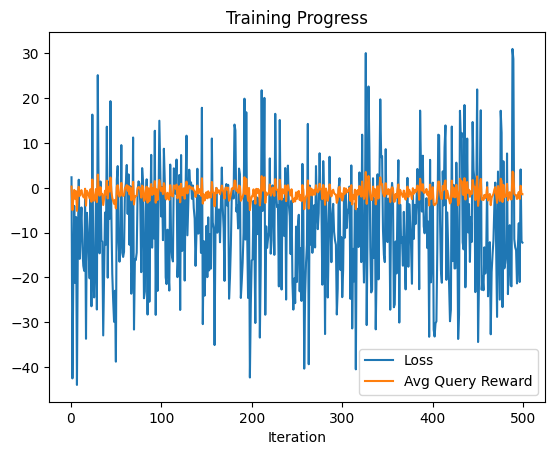

In [26]:
policy = train(inner_lr=0.01,
               outer_lr=0.001,
               inner_steps=1,
               meta_batch_size=20,
               max_episode_len=1000
)

In [27]:
env = HalfCheetahBackward()
evaluate(policy, env, num_episodes=10)

Mean Reward: 14.433839466805182


In [28]:
show_video('./Final_Evaluation.mp4')